# Project 03: Gibbs Sampling (Random Algorithm)

In [32]:
pip install numpy pandas logomaker

Note: you may need to restart the kernel to use updated packages.


In [13]:
import matplotlib.pyplot as plt

In [2]:
import random
import numpy as np
import seqlogo as sl

#import function for building sequence motif & idenfitying seqs matching to motif
from data_readers import *
from seq_ops import get_seq
from motif_ops import *

---
## Implement Gibbs Sampler


Gibbs sampling is a MCMC approach to identify enrichments. Here we will implement a method to identify motifs from a set of regions. 

Important considerations:
- We will need to score each sequence with a PWM using the `score_kmer()` or `score_sequence()` functions
    - You will need to investigate into the help documenation and libraries to identify how best to use these functions. 
- These sites are often not strand-specific and so both scores on the negative as well as positive strand should be considered
- To select a random sequence, use `random.randint()` or `numpy.random.randint()`
- To select a new position $m$ (as defined below) use `random.choices()` or `numpy.random.choice()`  

Assumptions: 
- We know $k$ as the length of expected motif
- Each sequence contains the motif



```
GibbsMotifFinder(DNA, k-length)
    random pick of k-length sequences from each line of DNA as Motifs
    for j ← 1 to 10000 or Motifs stops changing
        i ← Random(N) where N is number of DNA entries
        PWM ← PWM constructed from all Motifs except for Motifi
        Motifi ← select position m from PWM-scored k-mers in DNAi in probabilistic fashion from score distribution
    return PFM
```

Probability of chosing position $m = \frac{A_{m}}{\sum_{l}A_{l}}$ for positions $l$ in DNAi


**Note:** I have also added a function to `motif_ops.py` that will calculate the information content of your motifs. This is useful to observe the progression of your Gibbs sampler as well as a measure of convergence. You can use this function as `IC = pfm_ic(pfm)`. You should expect a slow increase of IC until it plateaus such as in the plot below from your lecture slides:

<center><img src='figures/Gibbs_Sampling.png'/ width=600px></center>

---
# Project Start

code before any change

In [ ]:
def GibbsMotifFinder(seqs, k, seed=None):
    """
    Find a position frequency matrix (PFM) from a list of DNA sequences
    using Gibbs sampling.

    Args:
        seqs (list[str]): DNA sequences, not necessarily the same length.
        k (int): Length of the motif to find.
        seed (int, default=None): Seed for NumPy random number generator.

    Returns:
        np.ndarray: Final PFM with dimensions 4 x k.
    """

    # Seeded random number generator
    rng = np.random.default_rng(seed)

    # Randomly select one k-mer from each sequence

    Motifs = []

    for seq in seqs:

        # Choose a valid starting position
        start_pos = rng.integers(0, len(seq) - k + 1)

        # Extract the initial k-mer
        chunk = seq[start_pos:start_pos + k]

        # Store the initial motif guess
        Motifs.append(chunk)


    # Store information content values for convergence checking
    ic_history = []

    for round_num in range(10000):

        # Randomly choose one sequence to hold out
        i = rng.integers(0, len(seqs))

        other_motifs = []

        for j in range(len(Motifs)):
            if j != i:
                other_motifs.append(Motifs[j])

        pfm = build_pfm(other_motifs, k)
        pwm = build_pwm(pfm)


        # Sequence currently being held out
        left_out_seq = seqs[i]

        best_scores = []
        best_chunks = []

        for m in range(len(left_out_seq) - k + 1):

            # Forward-strand k-mer
            forward_chunk = left_out_seq[m:m + k]

            # Reverse complement of the same position
            reverse_chunk = reverse_complement(forward_chunk)

            # Score both orientations
            forward_score = score_kmer(forward_chunk, pwm)
            reverse_score = score_kmer(reverse_chunk, pwm)

            # Keep the better orientation for this position
            if forward_score >= reverse_score:
                best_scores.append(forward_score)
                best_chunks.append(forward_chunk)

            else:
                best_scores.append(reverse_score)
                best_chunks.append(reverse_chunk)


        scores = np.array(best_scores)

        # Subtracting the maximum does not change the relative
        # probabilities, but makes the calculation more stable.
        weights = 2 ** (scores - np.max(scores))

        # Normalize weights so that they sum to 1
        weights = weights / weights.sum()


        new_position = rng.choice(
            len(best_chunks),
            p=weights
        )

        # Replace the motif for the held-out sequence
        Motifs[i] = best_chunks[new_position]

        current_pfm = build_pfm(Motifs, k)
        current_ic = pfm_ic(current_pfm)

        ic_history.append(current_ic)

        # Compare current information content with the value
        # approximately 100 iterations earlier
        if len(ic_history) > 100:

            if np.isclose(
                current_ic,
                ic_history[-101]
            ):
                break

    final_pfm = build_pfm(Motifs, k)

    return final_pfm

In [9]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
seq_file="/Users/graziano.peregrino/Desktop/6250/assignment-3/project03 (1)/data/GCF_000009045.1_ASM904v1_genomic.fna"
gff_file="/Users/graziano.peregrino/Desktop/6250/assignment-3/project03 (1)/data/GCF_000009045.1_ASM904v1_genomic.gff"

seqs = []

for name, seq in get_fasta(seq_file): # For each entry in our FASTA file
    for gff_entry in get_gff(gff_file): # For each entry in our GFF file
        if gff_entry.type == 'CDS': # If this is a coding sequence
            promoter_seq = get_seq(seq, gff_entry.start, gff_entry.end, gff_entry.strand, 50) # Extract 50 bp as a promoter
    
            """
            Because the gibbs sampling assumption is broken in just using promoters,
            and because it takes very long time to randomly progress through so many
            regions, for this example we will pre-filter for sequences that all contain
            part of the shine-dalgarno motif:
            """
            if "AGGAGG" in promoter_seq:
                seqs.append(promoter_seq)

---
# Driver Program
Don't change any of the code here. If you have completed the project by following the coding by contract, the following code should work.

In [10]:
# Run the gibbs sampler:
promoter_pfm = GibbsMotifFinder(seqs,10 )

# Plot the final pfm that is generated: 
#sl.seqlogo(sl.CompletePm(pfm = promoter_pfm.T))

In [11]:
print(promoter_pfm)
print(pfm_ic(promoter_pfm))

[[391 458 832   7   6 834   2   7 373 323]
 [102  93   0   0   1   0   0   0 102  83]
 [104 125   0 827 829   3 834 830 154 228]
 [240 161   5   3   1   0   1   0 208 203]]
12.381794612454424


---
# Challenge Yourself
Now that you potentially have a working skeleton of the project, try to work with the new NRF1 ChIP-seq data: `data/nrf1_gibbs.fa`.

Upon inspection, you will see that it is just a FASTA file. Since it is a FASTA file, you already have an example in the code above on how to access FASTA files. It is up to you to do the correct data ingest with it, though.

---
# NRF1 Driver Program
Modify the code below and test your Gibbs Sampler.

In [12]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
nrf1_file="data/nrf1_gibbs.fa" 

nrf1_peaks = []

#Data ingest of nrf1_peaks
for name, seq in get_fasta(nrf1_file):   #FOR each (name, seq) entry returned by get_fasta(nrf1_file)
    nrf1_peaks.append(seq)  #add seq directly to nrf1_peaks (no filtering needed)

# Run the gibbs sampler:
nrf1_pfm = GibbsMotifFinder(nrf1_peaks, 10)

# Plot the final pfm that is generated: 
#sl.seqlogo(sl.CompletePm(pfm = nrf1_pfm.T))

In [ ]:
#normalize
promoter_freq = (nrf1_pfm /nrf1_pfm.sum(axis=0, keepdims=True))

bases = np.array(["A", "C", "G", "T"])
consensus = "".join(bases[np.argmax(promoter_freq, axis=0)])

print("Consensus:", consensus)

Consensus: GGGCCCCGGG


PFM shape: (4, 10)

PFM:
[[19171 19613 19854 19402 20266 19734 19902 19559 19024 19634]
 [25625 24415 24446 26411 26832 27073 26108 24867 24913 25252]
 [26303 26548 26844 25798 24324 24846 24961 26791 27328 25806]
 [18962 19485 18917 18450 18639 18408 19090 18844 18796 19369]]

Number of motifs contributing to each position:
[90061 90061 90061 90061 90061 90061 90061 90061 90061 90061]

Normalized nucleotide frequencies:
[[0.213 0.218 0.22  0.215 0.225 0.219 0.221 0.217 0.211 0.218]
 [0.285 0.271 0.271 0.293 0.298 0.301 0.29  0.276 0.277 0.28 ]
 [0.292 0.295 0.298 0.286 0.27  0.276 0.277 0.297 0.303 0.287]
 [0.211 0.216 0.21  0.205 0.207 0.204 0.212 0.209 0.209 0.215]]

Column sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


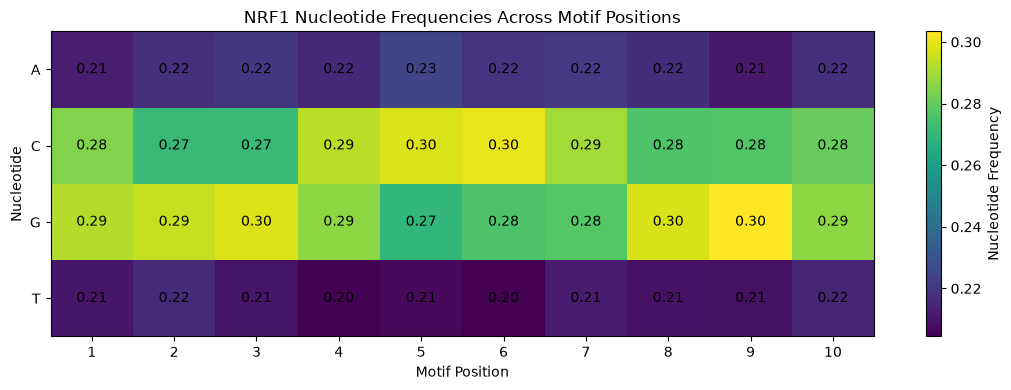

In [ ]:
#HEATMAP PLOT
print("PFM shape:", nrf1_pfm.shape)

print("\nPFM:")
print(nrf1_pfm)

print("\nNumber of motifs contributing to each position:")
print(nrf1_pfm.sum(axis=0))

nrf1_freq = (
    nrf1_pfm /
    nrf1_pfm.sum(axis=0, keepdims=True)
)


# Check that each motif position sums to 1
print("\nNormalized nucleotide frequencies:")
print(np.round(nrf1_freq, 3))

print("\nColumn sums:")
print(np.round(nrf1_freq.sum(axis=0), 3))


bases = ["A", "C", "G", "T"]

fig, ax = plt.subplots(figsize=(11, 4))


# Create heatmap
im = ax.imshow(nrf1_freq, aspect="auto")
ax.set_xticks(range(nrf1_freq.shape[1]))
ax.set_xticklabels(range(1, nrf1_freq.shape[1] + 1))
ax.set_yticks(range(len(bases)))
ax.set_yticklabels(bases)

ax.set_xlabel("Motif Position")
ax.set_ylabel("Nucleotide")

ax.set_title("NRF1 Nucleotide Frequencies Across Motif Positions")

for nucleotide in range(nrf1_freq.shape[0]):
    for position in range(nrf1_freq.shape[1]):
        ax.text(position,nucleotide,
            f"{nrf1_freq[nucleotide, position]:.2f}",
            ha="center",va="center")

colorbar = fig.colorbar(im, ax=ax)
colorbar.set_label("Nucleotide Frequency")

plt.tight_layout()
plt.show()